# Introduction 

 When people study a list with a lot of items from the same category on the list, they will often falsely recognize a word that is from that category, even if it wasn't present on the list. <br> <br> In this project, we will use **MINERVA** to emulate human memory, and use **sentence-transformer** to encode words as semantic vectors.
 
  We are aiming to explore whether MINERVA can account for false recognition observed in human memory experiments.

The word lists used in this project are taken from the following article: <br><br> Stadler, M.A., Roediger, H.L. & McDermott, K.B. Norms for word lists that create false memories. Memory & Cognition 27, 494–500 (1999). https://doi.org/10.3758/BF03211543  

The words list structure are as follows: 

* 36 semantic categories 
* Each category includes: 
    *  1 lure word
        * lure words are those words strongly associated with the category but not presented when learning that category
    *  15 study words 

# Lexicon List 

The word lists (including study words and lure words) are stored in a `.txt` file.<br> <br>In this section, we will load those lists and give a brief description of the data structure.

In [2]:
# Load word list from txt file and store in a dictionary
# the key is the lure words of that category and the value is the study words in that category

file_path=r"C:\Users\28718\Desktop\2024-2025\vanderbilt\PSY 4775 Human Memory\Chang Xu project\semantic_category_lists.txt"

category_dict = {}

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        if ':' in line:
            category, words = line.strip().split(":", 1)
            word_list = [w.strip() for w in words.split(",") if w.strip()]
            category_dict[category.strip()] = word_list


print(category_dict)  


{'*ANGER': ['mad', 'fear', 'hate', 'rage', 'temper', 'fury', 'ire', 'wrath', 'happy', 'fight', 'hatred', 'mean', 'calm', 'emotion', 'enrage'], '*ARMY': ['Navy', 'soldier', 'United States', 'rifle', 'Air Force', 'draft', 'military', 'Marines', 'march', 'infantry', 'captain', 'war', 'uniform', 'pilot', 'combat'], '*BLACK': ['white', 'dark', 'cat', 'charred', 'night', 'funeral', 'color', 'grief', 'blue', 'death', 'ink', 'Bottom', 'coal', 'brown', 'gray'], '*BREAD': ['butter', 'food', 'eat', 'sandwich', 'rye', 'jam', 'milk', 'flour', 'jelly', 'dough', 'crust', 'slice', 'wine', 'loaf', 'toast'], '*CAR': ['truck', 'bus', 'train', 'automobile', 'vehicle', 'drive', 'jeep', 'Ford', 'race', 'keys', 'garage', 'highway', 'sedan', 'van', 'taxi'], '*CHAIR': ['table', 'sit', 'legs', 'seat', 'couch', 'desk', 'recliner', 'sofa', 'wood', 'cushion', 'swivel', 'stool', 'sitting', 'rocking', 'bench'], '*CITY': ['town', 'crowded', 'state', 'capital', 'streets', 'subway', 'country', 'New York', 'village', 'm

In [3]:
# cleaning the keys of the dictionary by removing leading asterisks
# and printing the cleaned keys list

keys_list = list(category_dict.keys()) 
cleaned_keys_list = [key.lstrip('*') for key in keys_list] 
print(cleaned_keys_list)  


['ANGER', 'ARMY', 'BLACK', 'BREAD', 'CAR', 'CHAIR', 'CITY', 'COLD', 'CUP', 'DOCTOR', 'FLAG', 'FOOT', 'FRUIT', 'GIRL', 'HIGH', 'KING', 'LION', 'MAN', 'MOUNTAIN', 'MUSIC', 'NEEDLE', 'PEN', 'RIVER', 'ROUGH', 'RUBBER', 'SHIRT', 'SLEEP', 'SLOW', 'SMELL', 'SMOKE', 'SOFT', 'SPIDER', 'SWEET', 'THIEF', 'TRASH', 'WINDOW']


In [4]:
# printing the values of the dictionary

value_list = list(category_dict.values()) 
print(value_list)

[['mad', 'fear', 'hate', 'rage', 'temper', 'fury', 'ire', 'wrath', 'happy', 'fight', 'hatred', 'mean', 'calm', 'emotion', 'enrage'], ['Navy', 'soldier', 'United States', 'rifle', 'Air Force', 'draft', 'military', 'Marines', 'march', 'infantry', 'captain', 'war', 'uniform', 'pilot', 'combat'], ['white', 'dark', 'cat', 'charred', 'night', 'funeral', 'color', 'grief', 'blue', 'death', 'ink', 'Bottom', 'coal', 'brown', 'gray'], ['butter', 'food', 'eat', 'sandwich', 'rye', 'jam', 'milk', 'flour', 'jelly', 'dough', 'crust', 'slice', 'wine', 'loaf', 'toast'], ['truck', 'bus', 'train', 'automobile', 'vehicle', 'drive', 'jeep', 'Ford', 'race', 'keys', 'garage', 'highway', 'sedan', 'van', 'taxi'], ['table', 'sit', 'legs', 'seat', 'couch', 'desk', 'recliner', 'sofa', 'wood', 'cushion', 'swivel', 'stool', 'sitting', 'rocking', 'bench'], ['town', 'crowded', 'state', 'capital', 'streets', 'subway', 'country', 'New York', 'village', 'metropolis', 'big', 'Chicago', 'suburb', 'county', 'urban'], ['hot'

In [5]:
# creating a new list with cleaned keys and values for further processing 

lure_list = cleaned_keys_list.copy() 
lexicon_list =value_list.copy()

In [6]:
# showing the first cleaned keys and accordingly values lists

print(f'Lexical in First Category: {lexicon_list[0]}') 
print(f'Lure in First Category: {lure_list[0]}')
print(f'Number of Words in One Category: {len(lexicon_list[0])}')
print(f'Total Number of Lure words: {len(lure_list)}')
print(f'Total Number of Categories: {len(lure_list)}')


Lexical in First Category: ['mad', 'fear', 'hate', 'rage', 'temper', 'fury', 'ire', 'wrath', 'happy', 'fight', 'hatred', 'mean', 'calm', 'emotion', 'enrage']
Lure in First Category: ANGER
Number of Words in One Category: 15
Total Number of Lure words: 36
Total Number of Categories: 36


# Using Sentence-transformer to encode

In this section, we use a pre-trained `sentence-transformer` model (`all-MiniLM-L6-v2`) to encode study words and lure words<br><br> The output variables are: 

**lexicon_embeddings**: 3D Numpy array (36, 15, 384)
* 36 categories
* 15 study words per category 
* Each words encoded as a 384 dimension vectors


**lure_embeddings**: 2D Numpy array (36, 384) 
* 36 lure words 
* Each words encoded as a 384 dimension vectors

In [7]:
from sentence_transformers import SentenceTransformer 
import numpy as np 
model = SentenceTransformer('all-MiniLM-L6-v2')

In [8]:
lexicon_embeddings =[] 
for lexicon in lexicon_list: 
    embeddings = model.encode(lexicon)  
    lexicon_embeddings.append(embeddings) 
    
lexicon_embeddings = np.stack(lexicon_embeddings)

lure_embeddings = np.array(model.encode(lure_list))

In [9]:
# Printing the shapes of the embeddings

print(lexicon_embeddings.shape)
print(lure_embeddings.shape)

(36, 15, 384)
(36, 384)


In [10]:
# Printing the embeddings of first lexicon and lure

print(f'Embeddings in first category: {lexicon_embeddings[0]}')
print(f'Embeddings of first lure: {lure_embeddings[0]}')

Embeddings in first category: [[-0.04045684 -0.0337536  -0.0327006  ...  0.03209146 -0.02405776
   0.00428838]
 [ 0.01594562  0.04997986  0.00983783 ... -0.05576961  0.00406708
   0.04680562]
 [-0.05927399  0.03624208  0.01411925 ...  0.06063902  0.05526675
   0.07842972]
 ...
 [ 0.023095    0.01108236 -0.01214589 ...  0.07930811  0.0009922
   0.0617782 ]
 [-0.02154585  0.03732713  0.01316349 ...  0.01634452 -0.02443181
   0.04810457]
 [-0.02790061  0.04859836  0.02428837 ... -0.02440728  0.05171574
   0.06610321]]
Embeddings of first lure: [-2.59897355e-02  1.10025778e-02  1.66750327e-03  3.54377963e-02
  3.99865694e-02  2.40156241e-02  9.98316407e-02  3.93092670e-02
  5.84405288e-02 -3.75795625e-02  2.26167142e-02 -6.32127970e-02
  3.95318121e-03 -6.44873306e-02 -4.06248309e-02  2.00787522e-02
 -5.73428497e-02 -3.22842412e-02 -4.31563556e-02 -4.17390317e-02
 -7.83876702e-02  8.11816528e-02 -1.05655998e-01  3.74271534e-02
 -5.16918227e-02  9.06542838e-02 -6.13297336e-03  8.03298429e-0

In [11]:
ncategories = lexicon_embeddings.shape[0]  # how many categories we have 
ncategoryitems = lexicon_embeddings.shape[1] # how many items in each category
nfeatures = lexicon_embeddings.shape[2] # how many features in each item
nallitems =ncategories * ncategoryitems # how many items in total

# Printing the number of categories, items in each category, features of each item, and total study words
print(f'Number of Categories: {ncategories}')
print(f'Number of Items in Each Category: {ncategoryitems}')
print(f'Number of Features in Each Item: {nfeatures}')
print(f'Total Number of Study Words: {nallitems}')

Number of Categories: 36
Number of Items in Each Category: 15
Number of Features in Each Item: 384
Total Number of Study Words: 540


# Calculating the similarity of lure words and category words

In order to understand the differences of echo intensity

Here, we calculate two types of similarities: 
*  the similarity between study words in each category and lure words 
*  the similarity between categories 

From the output, we can see that the similarity between lure words and study words in the same category mainly concentrate on 0.47

* The average value is 0.47
* The max value is 0.59 
* The min value is 0.26 

This indicates that while lure words are not identical to the study words, most of them are moderate semantically related with study words, which can activate false memory. 

People my mistakenly recall or recognize them as been studied before. 

Also, some of the similarity values are relatively small. 

This may tell us threshold of activation of false memory may differ among categories, and the effectiveness of activation of false memory may depend on the similarity between lure words and study words. 


In [12]:
def cosine_similarity(a, b):
    """Compute the cosine similarity between two vectors"""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# key is the lure word, value is the average similarity with the words in the same category
lure_category_similarity = {}

for i in range(len(lure_embeddings)):
    lure = lure_embeddings[i]
    category_words = lexicon_embeddings[i]
    similarities = [cosine_similarity(lure, word) for word in category_words]
    average_similarity = np.mean(similarities)

    lure_word = lure_list[i]
    lure_category_similarity[lure_word] = average_similarity


sorted_similarity = dict(sorted(lure_category_similarity.items(), key=lambda x: x[1], reverse=True))


for word, sim in sorted_similarity.items():
    print(f"{word}: average similarity = {sim:.4f}")

print(f"Max similarity: {max(lure_category_similarity.values()):.4f}")
print(f"Min similarity: {min(lure_category_similarity.values()):.4f}")
print(f"Mean similarity: {np.mean(list(lure_category_similarity.values())):.4f}")


COLD: average similarity = 0.5970
ARMY: average similarity = 0.5859
CAR: average similarity = 0.5799
CITY: average similarity = 0.5634
MUSIC: average similarity = 0.5616
FRUIT: average similarity = 0.5577
CHAIR: average similarity = 0.5458
SMOKE: average similarity = 0.5431
DOCTOR: average similarity = 0.5393
BREAD: average similarity = 0.5289
FOOT: average similarity = 0.5263
SMELL: average similarity = 0.5255
BLACK: average similarity = 0.5125
SLEEP: average similarity = 0.5083
KING: average similarity = 0.5078
TRASH: average similarity = 0.5070
ANGER: average similarity = 0.5036
THIEF: average similarity = 0.4930
MOUNTAIN: average similarity = 0.4911
SHIRT: average similarity = 0.4848
RIVER: average similarity = 0.4822
GIRL: average similarity = 0.4656
PEN: average similarity = 0.4372
WINDOW: average similarity = 0.4351
SPIDER: average similarity = 0.4301
SOFT: average similarity = 0.4271
RUBBER: average similarity = 0.4253
CUP: average similarity = 0.4218
SLOW: average similarity =

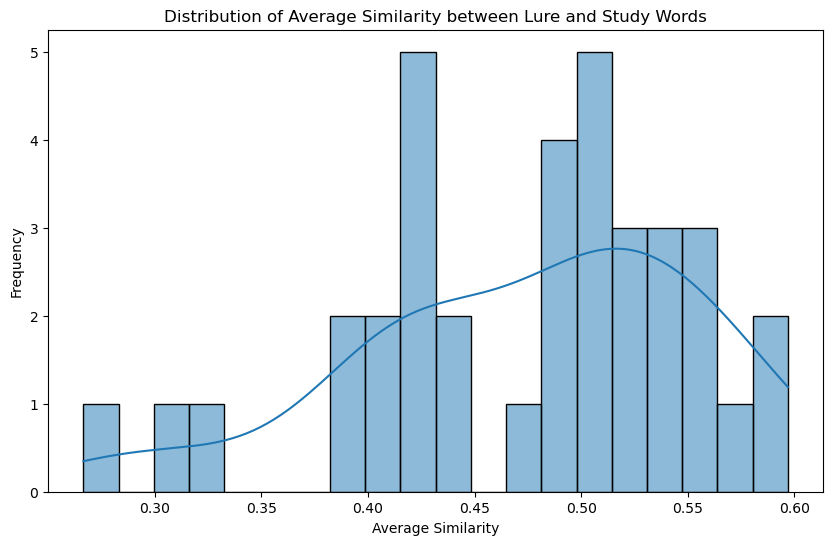

In [13]:
import matplotlib.pyplot as plt 
import seaborn as sns  

fig, ax = plt.subplots(figsize=(10, 6)) 
sns.histplot(lure_category_similarity, bins=20, kde=True, ax=ax) 
ax.set_title('Distribution of Average Similarity between Lure and Study Words')
ax.set_xlabel('Average Similarity')
ax.set_ylabel('Frequency')
plt.show()

From the output here, we can see the similarity between different categories are varied slightly, but most concentrate between 0.6 and 0.8. 

The highest value is 0.84.  

Both the mean value and the highest value are higher than those between lure words and their corresponding study words. 

In [14]:
# calculating the similarity between different categories

def compute_category_similarity(lexicon_embeddings): 
    ncategories = lexicon_embeddings.shape[0] 
    category_means = np.mean(lexicon_embeddings, axis=1)
    dot =np.dot(category_means, category_means.T) 
    norms = np.linalg.norm(category_means, axis=1) 
    norm_matrix = np.outer(norms, norms)
    similarity_matrix = dot / norm_matrix 
    return similarity_matrix

similarity_matrix = compute_category_similarity(lexicon_embeddings)
print(f'Similarity matrix shape: {similarity_matrix.shape}') 
print(f'Similarity matrix: {similarity_matrix}')
similarity_matrix 

Similarity matrix shape: (36, 36)
Similarity matrix: [[0.99999964 0.5892821  0.7175864  ... 0.6329318  0.60629207 0.6447838 ]
 [0.5892821  1.0000002  0.62328106 ... 0.6422276  0.53824204 0.5736387 ]
 [0.7175864  0.62328106 1.0000002  ... 0.672084   0.67748356 0.7334717 ]
 ...
 [0.6329318  0.6422276  0.672084   ... 1.0000001  0.6569994  0.6339575 ]
 [0.60629207 0.53824204 0.67748356 ... 0.6569994  1.         0.59979564]
 [0.6447838  0.5736387  0.7334717  ... 0.6339575  0.59979564 1.0000001 ]]


array([[0.99999964, 0.5892821 , 0.7175864 , ..., 0.6329318 , 0.60629207,
        0.6447838 ],
       [0.5892821 , 1.0000002 , 0.62328106, ..., 0.6422276 , 0.53824204,
        0.5736387 ],
       [0.7175864 , 0.62328106, 1.0000002 , ..., 0.672084  , 0.67748356,
        0.7334717 ],
       ...,
       [0.6329318 , 0.6422276 , 0.672084  , ..., 1.0000001 , 0.6569994 ,
        0.6339575 ],
       [0.60629207, 0.53824204, 0.67748356, ..., 0.6569994 , 1.        ,
        0.59979564],
       [0.6447838 , 0.5736387 , 0.7334717 , ..., 0.6339575 , 0.59979564,
        1.0000001 ]], dtype=float32)

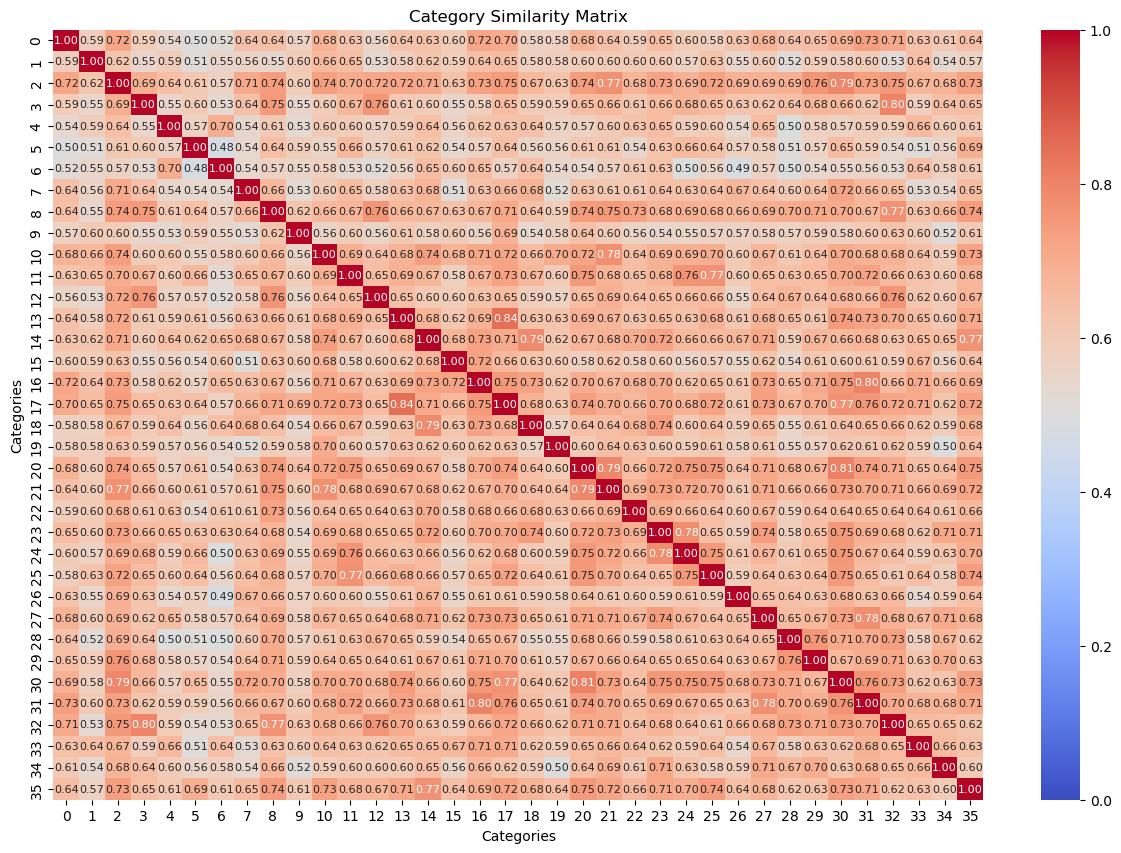

In [15]:

fig, ax = plt.subplots(figsize=(15, 10)) 
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', annot_kws={"size": 8},
            cmap="coolwarm",vmin=0, vmax=1, ax=ax) 
plt.title("Category Similarity Matrix") 
plt.xlabel("Categories") 
plt.ylabel("Categories")
plt.show()

# Instance Theory 

From previous part, we have loaded the lure words and study words, and use sentence-transformer to encode them. 

Now, we will use `MINERVA`  to emulate the false memory. 

There are 36 categories in the word list. We will set 2 types of learning conditions:

*  Learning random 18 categories at a time, which is used by Stadler, Roediger, & McDermott (1999)
*  Learning all 36 categories at the same time. 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
import seaborn as sns

rng = np.random.default_rng(416)

## False Memory when learning 18 categories at a time

According to Stadler, Roediger, & McDermott (1999), we will randomly choose 18 categories to learn. 

Also, we will define three types of probes: 
* Probe1: The 1st, 8th, 10th words in each learned categories 
* Probe2: The lure words which are semantically associated with the learned categories 
* probe3: Two words from each unlearned categories

By calculating the similarity between different kinds of probes, we find that they are not related with each other, which means that they may activate false memory to different extent

In [17]:
# Randomly select 18 categories to learn and the rest to unlearn 
# using the learned indices to select the corresponding embeddings from lexicon_embeddings
# put them together, and create a new study trace

def generate_study_traces(ncategories, lexicon_embeddings):
    all_categories = np.arange(ncategories) 
    learned_indices = rng.choice(all_categories, size=18, replace=False) 
    mask =np.isin(all_categories, learned_indices)
    unlearned_indices = all_categories[~mask]
    study_traces =lexicon_embeddings[learned_indices].reshape(-1, lexicon_embeddings.shape[-1]) 
    return learned_indices, unlearned_indices, study_traces

In [18]:
learned_indices, unlearned_indices, study_traces = generate_study_traces(ncategories, lexicon_embeddings)
print(f'Learned Indices: {learned_indices}')
print(f'Unlearned Indices: {unlearned_indices}')
print(f'Study Traces Shape: {study_traces.shape}')
print(f'Study Traces: {study_traces}')

Learned Indices: [15 18 25  3 35 23 14 28  7 26 12 34  9  0 21 17  6 10]
Unlearned Indices: [ 1  2  4  5  8 11 13 16 19 20 22 24 27 29 30 31 32 33]
Study Traces Shape: (270, 384)
Study Traces: [[ 0.03548698 -0.06560464 -0.00993497 ... -0.05388925 -0.03124184
  -0.08696106]
 [ 0.06871656  0.01953453 -0.03049047 ...  0.02012217  0.03624524
   0.01772746]
 [-0.01030511  0.03115547  0.00727601 ... -0.08780559  0.05484455
  -0.0207338 ]
 ...
 [-0.00505502  0.04517891  0.01394222 ... -0.01695699 -0.02994576
  -0.00394736]
 [-0.01963856  0.10962021 -0.03832091 ...  0.03443277  0.04672263
  -0.06453624]
 [-0.01110019  0.11167141 -0.03440722 ... -0.03978413 -0.02725095
  -0.0337702 ]]


In [19]:
def generate_probes(learned_indices, unlearned_indices, lexicon_embeddings, lure_embeddings): 
    probe1 = [] 
    for i in learned_indices: 
        words_embeddings = lexicon_embeddings[i]  
        probe1.extend([words_embeddings[0], words_embeddings[7], words_embeddings[9]]) 

    probe1 = np.array(probe1) 

    probe3=[] 
    for i in unlearned_indices: 
        words_embeddings = lexicon_embeddings[i]  
        select_2items =rng.choice(words_embeddings, size=2, replace=False) 
        probe3.extend(select_2items)  

    probe3 = np.array(probe3) 

    probe2=lure_embeddings[learned_indices] 

    all_probes = {
        "target_words": probe1,
        "lure_words": probe2,
        "new_category_words": probe3
    }
    return probe1, probe2, probe3, all_probes


In [20]:
# Probe1: The 1st, 8th, 10th words in the learned categories 
# Probe2: The lure words which are semantically associated with the learned categories 
# probe3: Two words from each unlearned categories 

probe1, probe2, probe3, all_probes = generate_probes(learned_indices, unlearned_indices, lexicon_embeddings, lure_embeddings)
print(f'Probe1 shape: {probe1.shape}') 
print(f'Probe2 shape: {probe2.shape}') 
print(f'Probe3 shape: {probe3.shape}') 

Probe1 shape: (54, 384)
Probe2 shape: (18, 384)
Probe3 shape: (36, 384)


In [21]:
# calculating the similarity between different probes 
# demonstrating probe1, probe2, and probe3 are not semantically related with each other

def probe_similarity(probe1, probe2): 
    similarity = np.dot(probe1, probe2.T) / (norm(probe1) * norm(probe2)) 
    return np.mean(similarity)

sim1_2 = probe_similarity(probe1, probe2)
sim1_3 = probe_similarity(probe1, probe3)   
sim2_3 = probe_similarity(probe2, probe3)
print(f'Similarity between probe1 and probe2: {sim1_2}')
print(f'Similarity between probe1 and probe3: {sim1_3}')
print(f'Similarity between probe2 and probe3: {sim2_3}')

Similarity between probe1 and probe2: 0.009206507354974747
Similarity between probe1 and probe3: 0.005953352432698011
Similarity between probe2 and probe3: 0.010903863236308098


In [22]:
# set the forget rate =0.3, emulating true memory decay

def generate_memorystack(learned_indices, lexicon_embeddings,F):
    memory_list = [] 

    for i in learned_indices: 
        words_embeddings = lexicon_embeddings[i]  
        word_embeddings = words_embeddings.copy() 

        forget_mask =rng.uniform(size=word_embeddings.shape) < F 
        word_embeddings[forget_mask] = 0 
        memory_list.append(word_embeddings) 

    memorystack =np.concatenate(memory_list, axis=0) 

    return memorystack
 


In [23]:
memorystack = generate_memorystack(learned_indices, lexicon_embeddings, F=0.3)
print(f'Memory stack shape: {memorystack.shape}')

Memory stack shape: (270, 384)


C:\Users\28718\AppData\Local\Temp\ipykernel_4412\660033845.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()
C:\Users\28718\AppData\Local\Temp\ipykernel_4412\660033845.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()
C:\Users\28718\AppData\Local\Temp\ipykernel_4412\660033845.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()
C:\Users\28718\AppData\Local\Temp\ipykernel_4412\660033845.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt

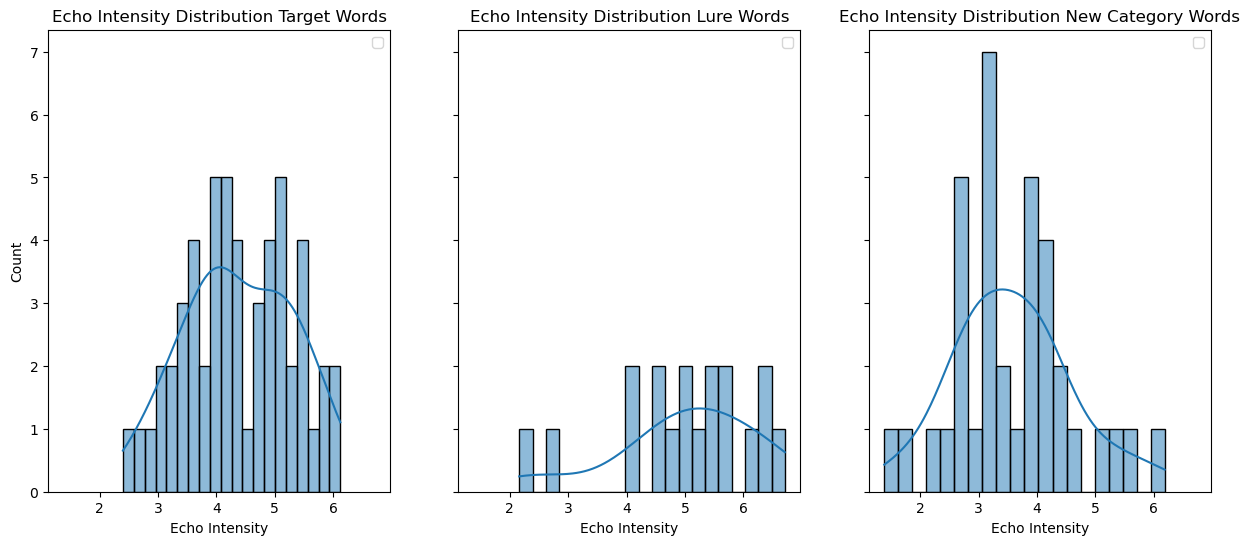

In [25]:
def calculate_echo_intensity(probe, memorystack):
    norms_probe = norm(probe)
    norms_memory = norm(memorystack, axis=1)
    dot_products = np.dot(memorystack, probe)
    normalized_dot_products = dot_products / (norms_probe * norms_memory)
    activation_values = normalized_dot_products ** 3
    echo_intensity = np.sum(activation_values) 
    return echo_intensity

echo_intensity_results = {}


for label, probes in all_probes.items():
    echoes = [calculate_echo_intensity(p, memorystack) for p in probes]
    echo_intensity_results[label] = echoes

fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True, sharex=True)
plots = ["target_words", "lure_words", "new_category_words"] 

for i, plot in enumerate(plots):
    sns.histplot(echo_intensity_results[plot], bins=20, kde=True, ax=ax[i])
    ax[i].set_title(f"Echo Intensity Distribution {plot.replace('_', ' ').title()}")
    ax[i].set_xlabel("Echo Intensity")
    ax[i].legend()

plt.legend()
plt.show()

From the three graphs, we can see that the echo intensity of lure words most concentrate between 5 and 6, which is much higher than target words and new category words. 

This indicates that the lure  words which is semantically associated with the learned category words can activate the false memory. 

Interestingly, the unlearned category words also have a relatively high echo intensity. This may due to the high similarity between categories.

From previous part, we have calculated that the echo intensity between categories, which concentrates between 0.6 and 0.8. The highest value is 0.8. 

In [26]:
# t_values_2a: Top 18 lure words with the highest false recognition rates  from the article (Picture 2A)
# t_values_2b: Bottom 18 lure words with the lowest false recognition rates from the article (Picture 2B)


t_values_2a = {
    "WINDOW": 84,"SMELL": 84,"COLD": 84,"ROUGH": 83,"CUP": 82,"SOFT": 81,"SLEEP": 80,"ANGER": 79,"SWEET": 78,"TRASH": 78,
    "CHAIR": 74,"SMOKE": 73,"HIGH": 72,"DOCTOR": 71,"THIEF": 70,"MOUNTAIN": 69,"SLOW": 69,"MUSIC": 69
}

t_values_2b = {
    "NEEDLE": 68,"RIVER": 67,"RUBBER": 67,"CITY": 64,"BREAD": 64,"FOOT": 62,"MAN": 61,"FLAG": 60,"SPIDER": 58,"GIRL": 58,"PEN": 57,
    "SHIRT": 54,"ARMY": 53,"BLACK": 49,"FRUIT": 45,"CAR": 42,"LION": 33,"KING": 27
}

t_values_all = {**t_values_2a, **t_values_2b}
print(t_values_all)

{'WINDOW': 84, 'SMELL': 84, 'COLD': 84, 'ROUGH': 83, 'CUP': 82, 'SOFT': 81, 'SLEEP': 80, 'ANGER': 79, 'SWEET': 78, 'TRASH': 78, 'CHAIR': 74, 'SMOKE': 73, 'HIGH': 72, 'DOCTOR': 71, 'THIEF': 70, 'MOUNTAIN': 69, 'SLOW': 69, 'MUSIC': 69, 'NEEDLE': 68, 'RIVER': 67, 'RUBBER': 67, 'CITY': 64, 'BREAD': 64, 'FOOT': 62, 'MAN': 61, 'FLAG': 60, 'SPIDER': 58, 'GIRL': 58, 'PEN': 57, 'SHIRT': 54, 'ARMY': 53, 'BLACK': 49, 'FRUIT': 45, 'CAR': 42, 'LION': 33, 'KING': 27}


In [27]:
F = 0.3
n_runs = 200
lure_echo_dict = {}

# select one lure word and calculate the echo intensity
# for each lure word, randomly select 17 categories from the remaining 35 categories as memory
# and calculate the echo intensity for each lure word

for idx in range(36):  
    probe = lure_embeddings[idx]
    lure_word = lure_list[idx]
    echo_list = []

    for _ in range(n_runs):
        # randomly select 17 categores from the remaining 35 categories as memory
        available = np.setdiff1d(np.arange(36), idx)
        selected_indices = np.random.choice(available, size=17, replace=False)

        memory_stack_2 = generate_memorystack(selected_indices, lexicon_embeddings, F)
        intensity = calculate_echo_intensity(probe, memory_stack_2)
        echo_list.append(intensity)

    # calculate mean echo intensity for each lure word
    lure_echo_dict[lure_word] = np.mean(echo_list)

# sort the dictionary by values (echo intensity) in ascending order
lure_echo_dict = dict(sorted(lure_echo_dict.items(), key=lambda x: x[1]))
print(lure_echo_dict)


{'FLAG': 1.8355752, 'SWEET': 2.0373013, 'MAN': 2.260814, 'THIEF': 2.854358, 'SLEEP': 2.8835626, 'RIVER': 3.2622094, 'LION': 3.342204, 'WINDOW': 3.3871355, 'NEEDLE': 3.4311414, 'CITY': 3.4358604, 'BREAD': 3.4506137, 'MOUNTAIN': 3.5749304, 'ANGER': 3.6336684, 'CHAIR': 3.7949648, 'RUBBER': 3.889975, 'DOCTOR': 3.9294622, 'SPIDER': 4.068108, 'SOFT': 4.0721984, 'GIRL': 4.1379366, 'ROUGH': 4.171949, 'PEN': 4.212559, 'SLOW': 4.254738, 'FOOT': 4.2789593, 'MUSIC': 4.2833695, 'KING': 4.3116646, 'HIGH': 4.3122406, 'ARMY': 4.4212956, 'CUP': 4.512143, 'COLD': 4.5413866, 'TRASH': 4.569554, 'FRUIT': 4.7966475, 'SMELL': 5.066046, 'SHIRT': 5.1993494, 'CAR': 5.395774, 'BLACK': 5.7225804, 'SMOKE': 6.056073}


In [ ]:
# chose the top 18 and bottom 18 lure words based on echo intensity
low_echo_lures = list(lure_echo_dict.keys())[:18]
high_echo_lures = list(lure_echo_dict.keys())[18:]

# get the words from t_values_2a and t_values_2b
t2a_words = list(t_values_2a.keys())  
t2b_words = list(t_values_2b.keys())  

# calculate the intersection of echo lures that we calculated (low and high) with t_values_2a and t_values_2b
lowecho_match_t2b = set(low_echo_lures) & set(t2b_words)
highecho_match_t2a = set(high_echo_lures) & set(t2a_words)


print(f"Intersection of calculated low echo intensity lure word with t_values_2a \n Numbers: {len(lowecho_match_t2b)}\n{sorted(lowecho_match_t2b)}\n")
print(f"Intersection of calculated high echo intensity lure word with t_values_2b \n Numbers: {len(highecho_match_t2a)} \n{sorted(highecho_match_t2a)}")


Intersection of calculated high echo intensity lure word with t_values_2a 
 Numbers: 9
['BREAD', 'CITY', 'FLAG', 'LION', 'MAN', 'NEEDLE', 'RIVER', 'RUBBER', 'SPIDER']

Intersection of calculated low echo intensity lure word with t_values_2b 
 Numbers: 9 
['COLD', 'CUP', 'HIGH', 'MUSIC', 'ROUGH', 'SLOW', 'SMELL', 'SMOKE', 'TRASH']


We find that words with the highest and lowest echo intensity exhibit considerable overlap with the behavioral false recognition groupings from Stadler, Roediger, & McDermott (1999). 9 out of 18 high echo intensity lures appear in the high false rate recognition group (t_values_2a), and 9 out of 18 low echo intensity lures appear in the low false rate recognition group (t_values_2b).

This suggests that the MINERVA model captures some structure aligned with empirical memory data

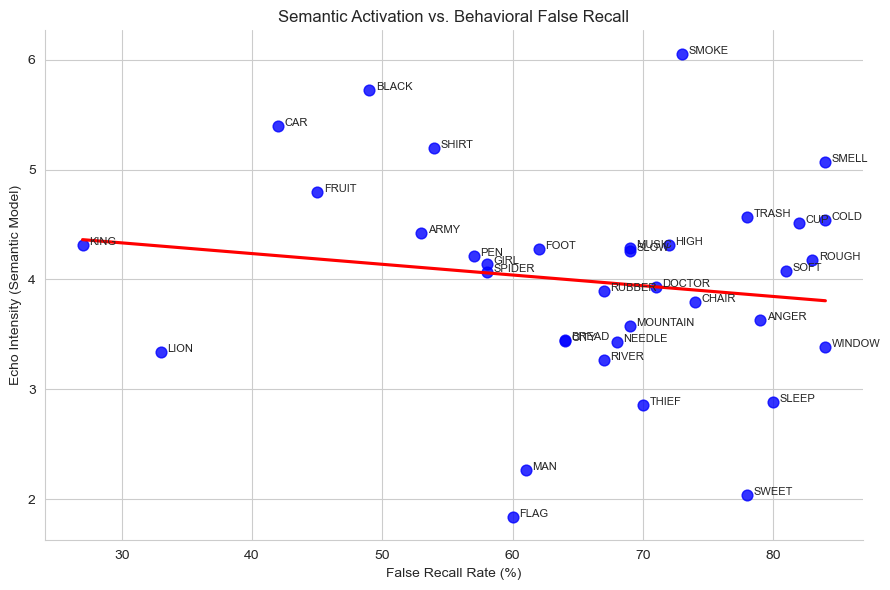

In [29]:
import pandas as pd

df = pd.DataFrame({
    "lure_word": list(lure_echo_dict.keys()),
    "echo_intensity": list(lure_echo_dict.values()),
    "false_recall": [t_values_all[word] for word in lure_echo_dict.keys()]
})

sns.set_style("whitegrid")

plot = sns.lmplot(data=df, x="false_recall", y="echo_intensity", 
    height=6, aspect=1.5, ci=None, scatter_kws={"s": 60, "color": "blue"}, line_kws={"color": "red"})

for i in range(df.shape[0]):
    plt.text(
        df["false_recall"][i] + 0.5, df["echo_intensity"][i], df["lure_word"][i], fontsize=8
    )

plt.xlabel("False Recall Rate (%)")
plt.ylabel("Echo Intensity (Semantic Model)")
plt.title("Semantic Activation vs. Behavioral False Recall")
plt.tight_layout()
plt.show()


In [30]:
# calculating the slope, intercept, r_value, p_value, and standard error of the regression line
from scipy.stats import linregress

words = [word for word in lure_echo_dict if word in t_values_all]
x = [t_values_all[word] for word in words]  # false recall
y = [lure_echo_dict[word] for word in words]  # echo intensity

slope, intercept, r_value, p_value, stderr = linregress(x, y)

print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"Pearson r: {r_value}")
print(f"p-value: {p_value}")
print(f"Standard error: {stderr}")


Slope: -0.009759443913438083
Intercept: 4.625235443853143
Pearson r: -0.14880329011315255
p-value: 0.38640943217337864
Standard error: 0.011122716906039502


It is very interesting that we found the false recall rate, which is the true behave data coming from Stadler, Roediger, & McDermott (1999), is not positively related with the MINERVA echo intensity.

We assume they should be positive, because the higher echo intensity means more likely this will be falsely recognized. 

But it is also worth noticing that the P-value is 0.37, which means these coefficients are not trustable. 

This result could be several explanations： 

1. The lure words and its corresponding category words are average semantically related. The mean value is 0.47, and the highest values is 0.59. And there is even some lure words are low semantically related with the category words, which has the value 0.26. This means that even the lure words are in the same category with corresponding study words,their vector representations in semantic space are not closely aligned . As a result, when a lure word is presented as a probe, it fails to strongly activate the corresponding memory traces, leading to a weaker echo intensity

2. The similarity between different categories are extremely high, even much higher than that between lure words and its corresponding category words. It concentrated between 0.6 and 0.8, and the highest value is 0.84.This may tell us that the category boundaries are blurred. In this case, when processing different lure words, the generated echo intensity are similar lacking of distinctiveness. MIVERVA model cannot differentiate between lure words with high or low false recall rates, leading to non significant relationship between echo intensity and the actual behavioral data. 

3. In the article, the words are recorded onto audio tape in a male voice at the rate of 1 word every 2 seconds. This auditory presentation may have additional influences on their memory, like the segmental, suprasegmental features, prosody, or accent. These perceptual and phonological factors are not represented in the semantic space.

## False Memory when learning words togerther

Now, we make an extra exploration. Here, we assume that participants will learn all the words together.The is 36 categories, and each categories have 15 words

We compare the similarity between lure probes and target probes

* target probes are those words chosen randomly from the studied words 

* lure probes are those words not learned but semantically associated with studied words



In [31]:
def create_memorystack_2(lexicon_embeddings, F=0.3, rng=None):
    rng = np.random.default_rng(416)
    ''' create a memory stack with forgetting rate F, and a study list'''

    ncategories = lexicon_embeddings.shape[0]
    ncategoryitems = lexicon_embeddings.shape[1]

    memorystack_list = []
    study_list = []

    for i in range(ncategories):
        items = lexicon_embeddings[i]                  
        study_list.append(items)                       

        forget_mask = rng.uniform(size=items.shape) < F
        items_copy = items.copy()
        items_copy[forget_mask] = 0                    
        memorystack_list.append(items_copy)

    memorystack_2 = np.concatenate(memorystack_list, axis=0)
    study_list = np.concatenate(study_list, axis=0)

    return memorystack_2, study_list


In [32]:
def calculate_echo_intensity_2(probe, memorystack_2):
    norms_probe = norm(probe)
    norms_memory = norm(memorystack_2, axis=1)
    dot_products = np.dot(memorystack_2, probe)
    normalized_dot_products = dot_products / (norms_probe * norms_memory)
    activation_values = normalized_dot_products ** 3
    echo_intensity = np.sum(activation_values) 
    return echo_intensity


In [33]:
memorystack_2, study_list = create_memorystack_2(lexicon_embeddings, F=0.3)
L=nallitems
n_trials = 1000

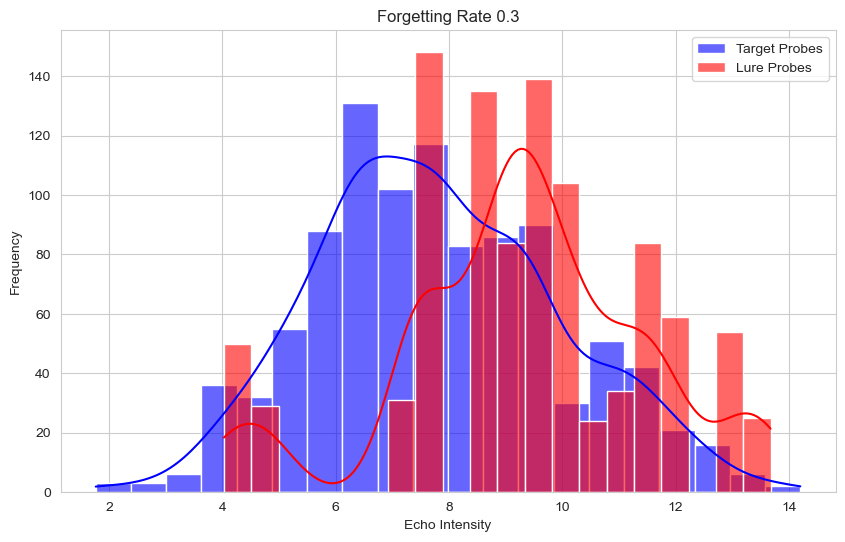

In [34]:

target_echo_intensities = []
lure_echo_intensities = [] 

for _ in range(n_trials):
   
    target_probe = study_list[rng.choice(L)]
    target_echo_intensities.append(calculate_echo_intensity(target_probe, memorystack_2))
    
    lure_index = rng.choice(ncategories)
    lure_probe = lure_embeddings[lure_index]
    lure_echo_intensities.append(calculate_echo_intensity(lure_probe, memorystack_2))


plt.figure(figsize=(10, 6))

sns.histplot(target_echo_intensities, bins=20, kde=True, color='blue', label='Target Probes', alpha=0.6)
sns.histplot(lure_echo_intensities, bins=20, kde=True, color='red', label='Lure Probes', alpha=0.6) 
plt.title('Forgetting Rate 0.3')
plt.xlabel('Echo Intensity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Here, we assumed that participants learned all words from the 36 semantic categories at once, with each category containing 15 words, resulting in a total of 540 studied items stored in memory.

Setting the forgetting rate as 0.3, we found that the echo intensity of lure words are systematically higher than that of target words. This indicates that MINERVA can explain the false memory phenomenon.